# Random Forest
#### Chris Brusie


Shape: (1599, 12)

Quality distribution:
 quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64
Fitting 5 folds for each of 210 candidates, totalling 1050 fits

Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 500}
Best CV accuracy: 0.6841

Test accuracy:  0.7000
±1-grade accuracy: 0.9719

Classification report:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.73      0.79      0.76       136
           6       0.66      0.74      0.70       128
           7       0.78      0.53      0.63        40
           8       1.00      0.33      0.50         3

    accuracy                           0.70       320
   macro avg       0.53      0.40      0.43       320
weighted avg       0.68      0.70      0.68       320

5-fold CV accuracy: 0.5760 ± 0.0326

Plot saved.


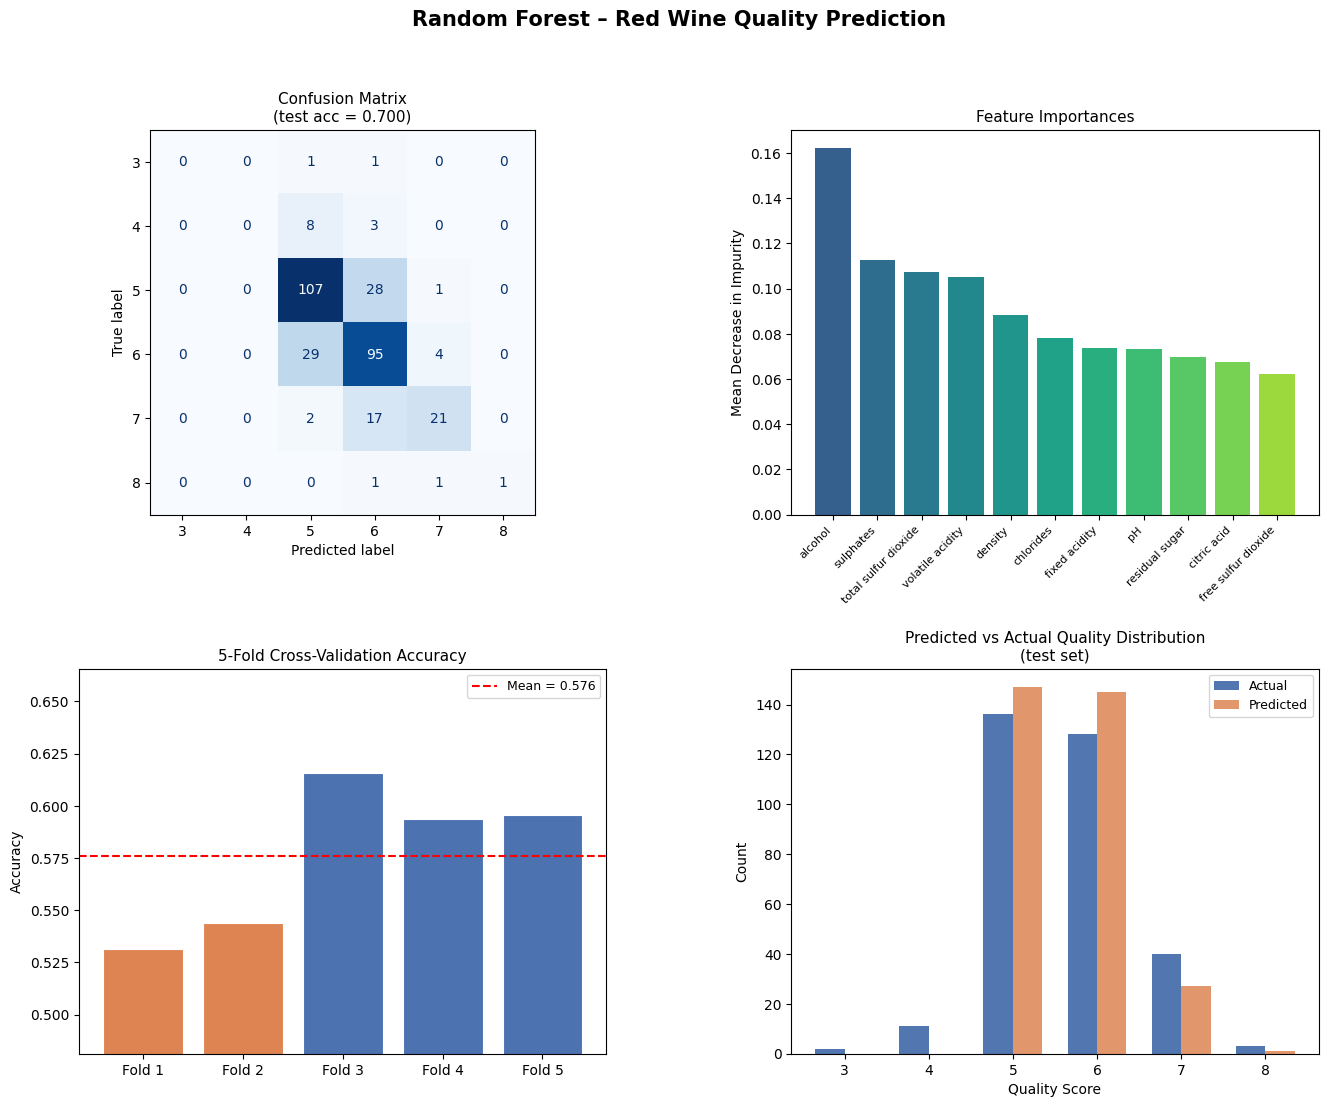

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings("ignore")

# ── 1. Load data ─────────────────────────────────────────────────────────────
cols = ["fixed acidity","volatile acidity","citric acid","residual sugar",
        "chlorides","free sulfur dioxide","total sulfur dioxide","density",
        "pH","sulphates","alcohol","quality"]
df = pd.read_csv("winequality-red-1.csv",
                 sep=";", skiprows=1, header=None, names=cols)
print("Shape:", df.shape)
print("\nQuality distribution:\n", df["quality"].value_counts().sort_index())

X = df.drop("quality", axis=1)
y = df["quality"]
feature_names = X.columns.tolist()

# ── 2. Train / test split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. Hyper-parameter tuning with GridSearchCV ──────────────────────────────
param_grid = {
    "n_estimators": [1, 10, 50, 100, 200, 500, 700],
    "max_depth":    [None, 10, 20, 50, 100],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    base_rf, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("\nBest params:", grid_search.best_params_)
print("Best CV accuracy: {:.4f}".format(grid_search.best_score_))

# ── 4. Evaluate best model ───────────────────────────────────────────────────
best_rf = grid_search.best_estimator_
y_pred  = best_rf.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("\nTest accuracy:  {:.4f}".format(test_acc))

# ±1 tolerance accuracy (common for ordinal quality scores)
tol1_acc = np.mean(np.abs(y_pred - y_test) <= 1)
print("±1-grade accuracy: {:.4f}".format(tol1_acc))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

# ── 5. Cross-validation on full dataset (best params) ───────────────────────
cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print("5-fold CV accuracy: {:.4f} ± {:.4f}".format(cv_scores.mean(), cv_scores.std()))

# ── 6. Plots ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Random Forest – Red Wine Quality Prediction", fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# (a) Confusion matrix
ax0 = fig.add_subplot(gs[0, 0])
classes = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax0, colorbar=False, cmap="Blues")
ax0.set_title(f"Confusion Matrix\n(test acc = {test_acc:.3f})", fontsize=11)

# (b) Feature importances
ax1 = fig.add_subplot(gs[0, 1])
importances = best_rf.feature_importances_
idx = np.argsort(importances)[::-1]
colors = plt.cm.viridis(np.linspace(0.3, 0.85, len(feature_names)))
bars = ax1.bar(range(len(feature_names)),
               importances[idx],
               color=[colors[i] for i in range(len(feature_names))])
ax1.set_xticks(range(len(feature_names)))
ax1.set_xticklabels([feature_names[i] for i in idx], rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Mean Decrease in Impurity")
ax1.set_title("Feature Importances", fontsize=11)

# (c) CV scores bar chart
ax2 = fig.add_subplot(gs[1, 0])
fold_labels = [f"Fold {i+1}" for i in range(len(cv_scores))]
bar_colors = ["#4C72B0" if s >= cv_scores.mean() else "#DD8452" for s in cv_scores]
ax2.bar(fold_labels, cv_scores, color=bar_colors, edgecolor="white", linewidth=0.8)
ax2.axhline(cv_scores.mean(), color="red", linestyle="--", linewidth=1.5,
            label=f"Mean = {cv_scores.mean():.3f}")
ax2.set_ylim(max(0, cv_scores.min() - 0.05), min(1, cv_scores.max() + 0.05))
ax2.set_ylabel("Accuracy")
ax2.set_title("5-Fold Cross-Validation Accuracy", fontsize=11)
ax2.legend(fontsize=9)

# (d) Predicted vs Actual distribution
ax3 = fig.add_subplot(gs[1, 1])
actual_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts   = pd.Series(y_pred).value_counts().sort_index()
all_classes   = sorted(set(actual_counts.index) | set(pred_counts.index))
x_pos = np.arange(len(all_classes))
w = 0.35
ax3.bar(x_pos - w/2, [actual_counts.get(c, 0) for c in all_classes],
        width=w, label="Actual", color="#345EA2", alpha=0.85)
ax3.bar(x_pos + w/2, [pred_counts.get(c, 0)  for c in all_classes],
        width=w, label="Predicted", color="#DD8452", alpha=0.85)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(all_classes)
ax3.set_xlabel("Quality Score")
ax3.set_ylabel("Count")
ax3.set_title("Predicted vs Actual Quality Distribution\n(test set)", fontsize=11)
ax3.legend(fontsize=9)

plt.savefig("figures/wine_rf_results.png", dpi=150, bbox_inches="tight")
print("\nPlot saved.")


